In [17]:
local_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260912_이상한 Breakdown Origin 여기\csv파일\General\1._Tape_far-near-far.csv"


max Ch1: 7.4688


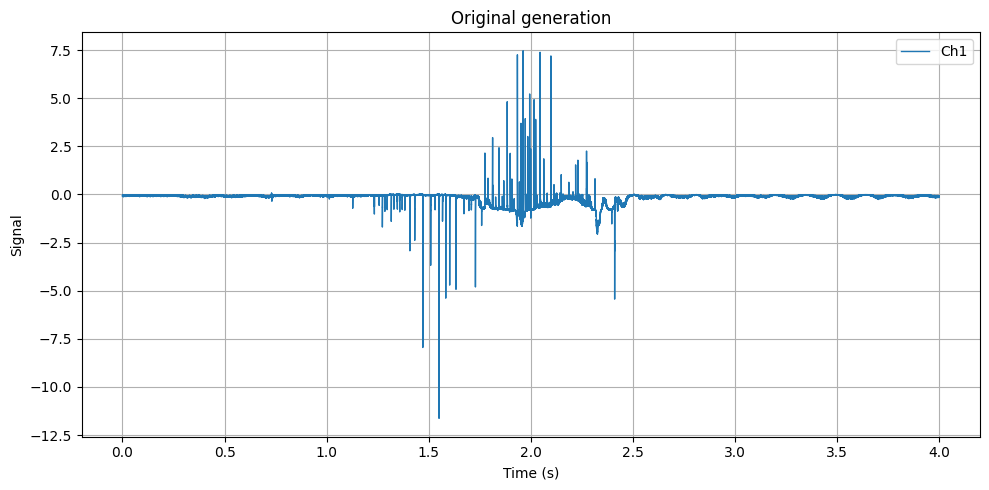

In [18]:
import os
from itertools import cycle

import matplotlib.pyplot as plt
import pandas as pd


PLOT_COLORS = [
    "#1f77b4",
    "#d62728",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]


def load_multichannel_csv(file_path, *, header=None, skiprows=0, current_scale=None):
    df = pd.read_csv(file_path, header=header, skiprows=skiprows)
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="all")

    if df.shape[1] < 2:
        raise ValueError("At least 2 columns are required: Time + 1 channel.")

    df.columns = ["Time"] + [f"Ch{i}" for i in range(1, df.shape[1])]
    df = df.dropna(subset=["Time"]).reset_index(drop=True)

    if current_scale is not None:
        signal_cols = list(df.columns[1:])
        df.loc[:, signal_cols] = df.loc[:, signal_cols] * float(current_scale)

    return df


def filter_time_range(df, time_range, *, shift_to_zero=False):
    if time_range is None:
        return df.copy()

    if len(time_range) != 2:
        raise ValueError("time_range must be None or a tuple like (start, end).")

    start, end = map(float, time_range)
    filtered = df[(df["Time"] >= start) & (df["Time"] <= end)].copy()

    if filtered.empty:
        raise ValueError(f"No data found in time range {time_range}.")

    filtered.reset_index(drop=True, inplace=True)

    if shift_to_zero:
        filtered.loc[:, "Time"] = filtered["Time"] - float(filtered.loc[0, "Time"])

    return filtered


def save_cut_csv(df, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    df.to_csv(file_path, index=False, header=False, encoding="utf-8-sig")


def plot_multichannel_overview(
    df,
    *,
    title,
    ylabel,
    figsize=(10, 5),
    y_range=None,
    legend=True,
):
    plt.figure(figsize=figsize)
    color_iter = cycle(PLOT_COLORS)

    for channel in df.columns[1:]:
        plt.plot(df["Time"], df[channel], label=channel, color=next(color_iter), linewidth=1.0)

    plt.xlabel("Time (s)")
    plt.ylabel(ylabel)
    plt.title(title)

    if y_range is not None:
        plt.ylim(y_range)

    plt.grid(True)

    if legend:
        plt.legend()

    plt.tight_layout()
    plt.show()


df = load_multichannel_csv(local_path, header=None)

for channel in df.columns[1:]:
    print(f"max {channel}: {df[channel].max(skipna=True):.4f}")

plot_multichannel_overview(
    df,
    title="Original generation",
    ylabel="Signal",
    figsize=(10, 5),
    legend=True,
)


In [19]:
t = 0.9
time_range = (t, t+2.0)  # MODIFY HERE
shift_time_to_zero = True

Filtered data saved at: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\4. 260830~실험\1. 실험자료\260912_이상한 Breakdown Origin 여기\csv파일\General\Cut_1._Tape_far-near-far.csv
Rows saved: 500,001


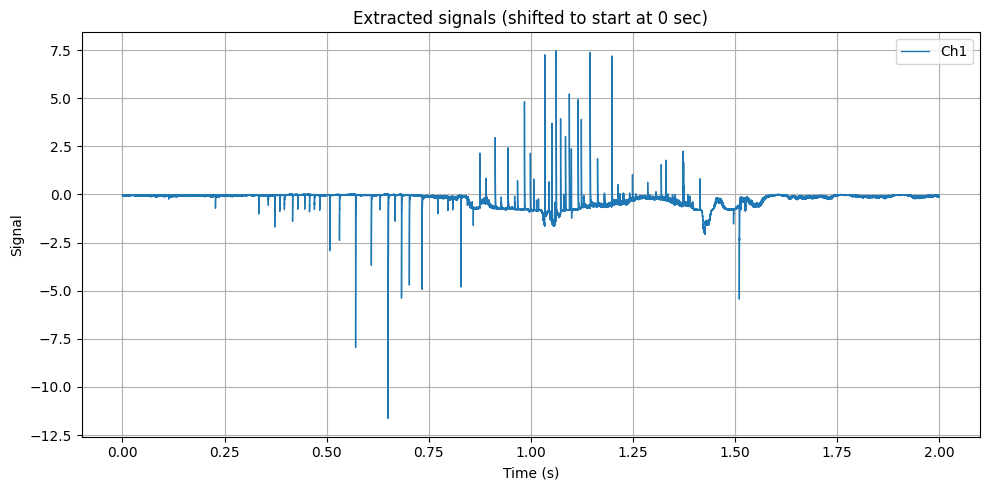

In [20]:
df_filtered = filter_time_range(df, time_range, shift_to_zero=shift_time_to_zero)

folder_path = os.path.dirname(local_path)
original_filename = os.path.basename(local_path)
filtered_file_name = f"Cut_{original_filename}"
filtered_file_path = os.path.join(folder_path, filtered_file_name)

save_cut_csv(df_filtered, filtered_file_path)
print(f"Filtered data saved at: {filtered_file_path}")
print(f"Rows saved: {len(df_filtered):,d}")

filtered_title = "Extracted signals"
if shift_time_to_zero:
    filtered_title += " (shifted to start at 0 sec)"

plot_multichannel_overview(
    df_filtered,
    title=filtered_title,
    ylabel="Signal",
    figsize=(10, 5),
    legend=True,
)
